<a href="https://colab.research.google.com/github/BiswarupMukherjee1/spacecraft-pose-failure-detection/blob/main/Exp7_deployment_efficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 7: Deployment efficiency

Biswarup Mukherjee

Experiments 1 to 6 asked which model is more accurate and whether it knows when it is
wrong. This experiment focusses on Deployment. A navigation function runs on a
radiation-hardened processor with no GPU, a fixed power budget and a hard deadline
between frames. A model that wins a benchmark and misses the deadline is not a
candidate.

This notebook measures the quantities that decide that: parameter count, model size,
multiply-accumulate operations, per-frame latency, peak activation memory, the effect
of INT8 quantisation, and the cost of Monte Carlo dropout.

For the cost of Monte Carlo Dropout, Experiment 5 needs 25 stochastic
passes to produce an epistemic estimate. That multiplies inference cost by 25, and
the deployment constraints should be identified at that number rather than at the
single-pass one.

## Where the model runs, and why that sets the budget

Rendezvous and docking navigation runs **onboard**. It cannot run on the ground:
a round trip to a ground station costs seconds at best and is unavailable outside
visibility windows, while the docking corridor is traversed in minutes and the
control loop closes in seconds. Active debris removal scenarios assume fully autonomous operation, which removes any
possibility of a ground-in-the-loop perception stage.

Onboard means one of these:

| Processor | What it is | Notes |
|---|---|---|
| GR740 (LEON4FT) | ESA next-generation quad-core SPARC at 250 MHz | radiation hardened, no GPU, no wide SIMD |
| GR712RC (LEON3FT) | dual-core SPARC at 100 MHz | radiation hardened, widely flown |
| RAD750 | PowerPC at 133-200 MHz | long flight heritage |
| Zynq UltraScale+ MPSoC | COTS FPGA plus ARM cores | the usual route for CNN inference in recent work |
| Myriad 2 VPU | COTS vision processor | flown on ESA's Phi-sat-1, the first European onboard AI demonstration |

A modern laptop CPU is roughly two to three orders of magnitude faster than a GR740
for this kind of arithmetic. So the single-thread CPU column measured below is an
**optimistic** proxy, not a pessimistic one. A model that is already slow there is
not a flight candidate without dedicated acceleration.

That is why the published work in this area is mostly about acceleration rather than
architecture: FPGA inference of the CNN stage (Cosmas and Asami, *Aerospace*, 2020),
and mixed-precision quantisation on a space-proven Xilinx MPSoC (Posso, Bois and
Savaria, IEEE NEWCAS 2024), which reports being 7.7 times faster and 19.5 times more
energy-efficient than the best previously reported spacecraft pose estimation
implementations.

## Transformer architectures and their reported cost

Transformer architectures are one of the directions considered for this work, so the
published evidence on their cost is recorded here.

**FastPose-ViT** (arXiv:2512.09792, December 2025). It uses a
Vision Transformer to regress the 6-DoF pose directly, deliberately avoiding the
iterative PnP stage on the grounds that it is too expensive for edge deployment. It
is evaluated on SPEED and SPEED+, and, most relevantly here, it is quantised and
deployed on an NVIDIA Jetson Orin Nano at about 75 ms per frame sequentially, and up
to 33 frames per second when the stages are pipelined. So a ViT for this task is
affordable on embedded hardware, at least on a Jetson-class device.

**PVSPE** (*Advances in Space Research*, 2024) takes the other route: a pyramid
vision transformer backbone inside a multitask network, with the feed-forward blocks
trimmed and an efficient channel attention module, specifically to keep the cost
down. Its stated motivation is that features from a pure CNN backbone may not resist
noise and occlusion as well as a transformer's global attention.

There is also recent work on compressing Vision Transformer foundation models for
on-orbit inference, demonstrated on the IMAGIN-e payload aboard the ISS
(arXiv:2512.01181), which is Earth observation rather than rendezvous but is the same
compression problem.

Two things follow. A transformer is not automatically ruled out on cost. And a Jetson
Orin Nano is not a radiation-hardened flight processor, so "runs at 33 FPS on a
Jetson" is a step towards flight readiness rather than a demonstration of it.

In [ ]:
!pip install -q opencv-contrib-python transformers 2>&1 | tail -1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
CODE = "/content/drive/MyDrive/SENER_PROJ2/code"
if CODE not in sys.path:
    sys.path.insert(0, CODE)
print("modules found:", sorted(f for f in os.listdir(CODE) if f.endswith(".py")))

Mounted at /content/drive
modules found: ['exp6_ekf_mc.py', 'exp7_efficiency.py', 'pose_models.py', 'sc_common.py', 'speedplus_data.py', 'speedplus_fetch.py']


In [ ]:
import copy, numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
import pose_models as PM
import exp7_efficiency as E7

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
INPUT_SHAPE = (1, 1, IMG_SIZE, IMG_SIZE)     # batch of 1: a filter sees one frame
N_RUNS = 50
N_MC = 25                                     # must match Experiment 5
CAMERA_HZ = 1.0                               # rendezvous cameras are often ~1 Hz
print("device:", device)
E7.print_flight_context()

device: cuda
Representative onboard processors:
  processor                 description                                   throughput      
  GR740 (LEON4FT)           ESA next-generation quad-core SPARC, 250 MHz  ~1700 DMIPS     
  GR712RC (LEON3FT)         dual-core SPARC, 100 MHz                      ~200 DMIPS      
  RAD750                    PowerPC, 133-200 MHz                          ~400 DMIPS      
  Zynq UltraScale+ MPSoC    COTS FPGA + ARM, used with mitigation         FPGA fabric     
  Myriad 2 VPU              COTS vision processor, flown on Phi-sat-1     ~100 GFLOPS     

  A modern laptop CPU is roughly two to three orders of magnitude
  faster than a GR740 for this kind of work. The single-thread CPU
  latency measured here is therefore an optimistic proxy: a model
  that is already slow in that column is not a flight candidate
  without dedicated acceleration.


## 1. Profile both models

Latency is measured at batch size 1, with a warm-up loop discarded and CUDA
synchronised around each timing, because CUDA calls are asynchronous and timing them
without synchronisation measures the launch and not the work. The median over many
runs is reported with the 95th percentile, since a navigation deadline cares about
the tail rather than the average.

In [ ]:
models = {}
m_cnn, tag_cnn = PM.build_model("cnn", p_drop=0.3)
models[f"CNN ({tag_cnn})"] = m_cnn
try:
    m_vit, tag_vit = PM.build_model("vit", p_drop=0.3, freeze_vit=True)
    models[f"ViT ({tag_vit})"] = m_vit
except Exception as e:
    print("ViT unavailable:", type(e).__name__, str(e)[:150])

rows = []
for name, m in models.items():
    print(f"profiling {name} ...")
    rows.append(E7.profile_model(m, name, INPUT_SHAPE, device=device, n_runs=N_RUNS))
print()
E7.print_profile_table(rows)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

profiling CNN (resnet18) ...
profiling ViT (dinov2-small-frozen) ...

model                   params M   size MB    GMACs   GPU ms   CPU ms  CPU-1t ms
--------------------------------------------------------------------------------
CNN (resnet18)             11.57      46.3     1.74      3.6     49.7       48.9
ViT (dinov2-small-frozen)     22.58      90.4     6.12      7.4    130.3      175.9


### Definitions

`GMACs` is multiply-accumulate operations per frame, in billions, and is the
hardware-independent measure of arithmetic work. Papers that quote FLOPs usually mean
twice this number; both are computed.

`CPU-1t` is single-threaded CPU latency. That is the column closest in spirit to a
flight processor, and it is still generous by a wide margin.

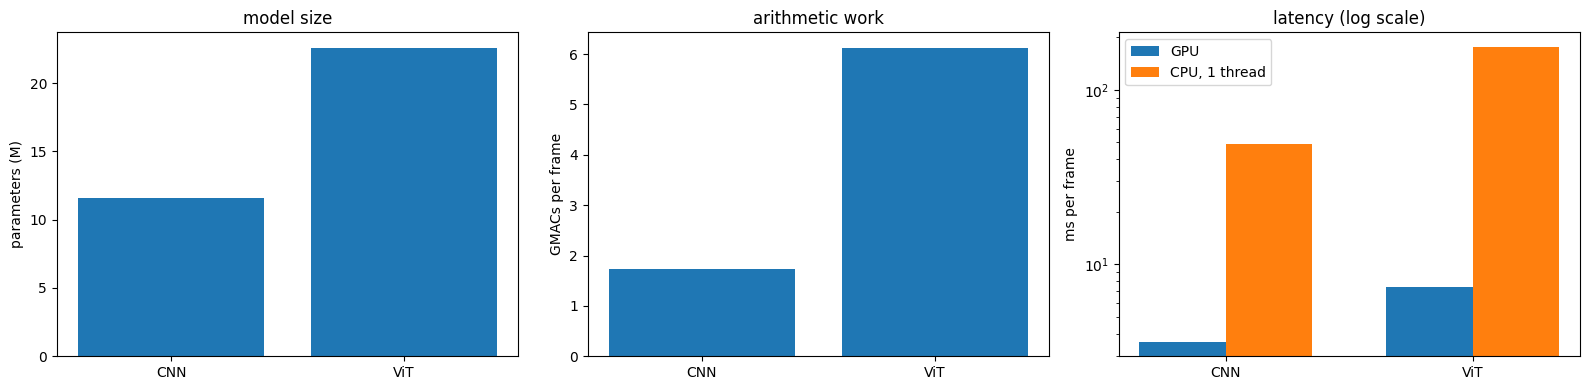

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
names = [r["name"].split(" (")[0] for r in rows]
axes[0].bar(names, [r["params_M"] for r in rows]); axes[0].set_ylabel("parameters (M)")
axes[0].set_title("model size")
axes[1].bar(names, [r["MACs_G"] for r in rows]); axes[1].set_ylabel("GMACs per frame")
axes[1].set_title("arithmetic work")
x = np.arange(len(rows)); w = 0.35
axes[2].bar(x - w/2, [r["gpu_ms"] for r in rows], w, label="GPU")
axes[2].bar(x + w/2, [r["cpu1_ms"] for r in rows], w, label="CPU, 1 thread")
axes[2].set_xticks(x); axes[2].set_xticklabels(names); axes[2].set_ylabel("ms per frame")
axes[2].set_yscale("log"); axes[2].legend(); axes[2].set_title("latency (log scale)")
plt.tight_layout(); plt.show()

## 2. INT8 quantisation

Dynamic quantisation stores weights as 8-bit integers and quantises activations on the
fly. It needs no calibration data and no retraining, which makes it the cheapest thing
to try and a lower bound on what quantisation can achieve.

It only converts `Linear` layers, so it helps a transformer, whose work is almost all
in linear projections, far more than a convolutional network, whose work sits in
`Conv2d`.

The output difference is checked as well, because a size reduction that changes the
predicted translation by metres is not a saving.

In [ ]:
qrows = []
for name, m in models.items():
    m_fp = copy.deepcopy(m).cpu().eval()
    try:
        m_q = E7.quantize_dynamic_int8(copy.deepcopy(m))
    except Exception as e:
        print(f"{name}: quantisation failed ({type(e).__name__})"); continue
    s0, s1 = E7.model_size_mb(m_fp), E7.model_size_mb(m_q)
    l0 = E7.measure_latency(m_fp, INPUT_SHAPE, "cpu", n_runs=20, threads=1)["median_ms"]
    l1 = E7.measure_latency(m_q,  INPUT_SHAPE, "cpu", n_runs=20, threads=1)["median_ms"]
    x = torch.randn(8, 1, IMG_SIZE, IMG_SIZE)
    with torch.no_grad():
        t0, _, _ = m_fp(x); t1, _, _ = m_q(x)
    d = float((t0 - t1).abs().max())
    qrows.append((name, s0, s1, l0, l1, d))
    print(f"{name}")
    print(f"   size    {s0:6.1f} -> {s1:6.1f} MB   ({s0/max(s1,1e-9):.2f}x smaller)")
    print(f"   latency {l0:6.1f} -> {l1:6.1f} ms   ({l0/max(l1,1e-9):.2f}x faster, 1 thread)")
    print(f"   largest change in predicted translation: {d:.4f} m")

CNN (resnet18)
   size      46.3 ->   45.2 MB   (1.03x smaller)
   latency   75.1 ->   49.4 ms   (1.52x faster, 1 thread)
   largest change in predicted translation: 0.0319 m
ViT (dinov2-small-frozen)
   size      90.4 ->   25.2 MB   (3.59x smaller)
   latency  132.8 ->  114.3 ms   (1.16x faster, 1 thread)
   largest change in predicted translation: 1.6153 m


## 3. Cost of the uncertainty estimate

Experiment 5 estimates epistemic uncertainty with Monte Carlo dropout, which runs the
whole network `N_MC` times per image. The accuracy tables never show this, and it
changes the deployment answer completely.

The comparison below is against a working assumption: that perception may use half the
interval between frames, leaving the rest for target detection, geometry, the filter
and guidance. That fraction is an assumption for this study, not a requirement from
any specification, and it is labelled that way.

Single forward pass:
  camera at 1 Hz -> 1000 ms between frames
  assumed perception budget (50%): 500 ms
  measured latency: 48.9 ms -> fits (0.10x the budget)

  camera at 1 Hz -> 1000 ms between frames
  assumed perception budget (50%): 500 ms
  measured latency: 175.9 ms -> fits (0.35x the budget)

With Monte Carlo dropout, 25 passes:
  CNN (resnet18): 48.9 ms x 25 = 1223 ms -> 0.82 effective FPS
  camera at 1 Hz -> 1000 ms between frames
  assumed perception budget (50%): 500 ms
  measured latency: 1223.1 ms -> DOES NOT FIT (2.45x the budget)

  ViT (dinov2-small-frozen): 175.9 ms x 25 = 4397 ms -> 0.23 effective FPS
  camera at 1 Hz -> 1000 ms between frames
  assumed perception budget (50%): 500 ms
  measured latency: 4397.3 ms -> DOES NOT FIT (8.79x the budget)



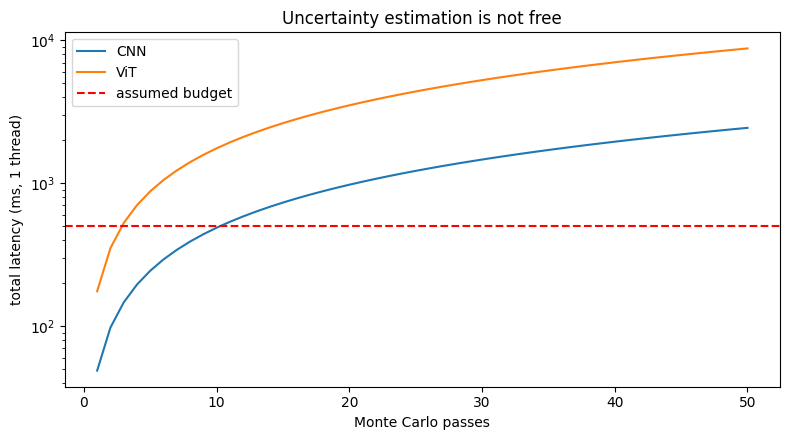

In [ ]:
print("Single forward pass:")
for r in rows:
    E7.budget_check(r["cpu1_ms"], camera_hz=CAMERA_HZ)
    print()

print(f"With Monte Carlo dropout, {N_MC} passes:")
for r in rows:
    mc = E7.mc_dropout_cost(r["cpu1_ms"], N_MC)
    print(f"  {r['name']}: {mc['single_pass_ms']:.1f} ms x {N_MC} = "
          f"{mc['total_ms']:.0f} ms -> {mc['effective_fps']:.2f} effective FPS")
    E7.budget_check(mc["total_ms"], camera_hz=CAMERA_HZ)
    print()

n_grid = np.arange(1, 51)
plt.figure(figsize=(8, 4.5))
for r in rows:
    plt.plot(n_grid, r["cpu1_ms"] * n_grid, label=r["name"].split(" (")[0])
plt.axhline(1000.0 / CAMERA_HZ * 0.5, c="r", ls="--", label="assumed budget")
plt.xlabel("Monte Carlo passes"); plt.ylabel("total latency (ms, 1 thread)")
plt.yscale("log"); plt.legend(); plt.title("Uncertainty estimation is not free")
plt.tight_layout(); plt.show()

### If the cost is prohibitive, following are the options:

Four options reduce or avoid this cost:


- **Fewer passes.** The estimate degrades gracefully; 5 passes is lesser than 25 but it is
  a good estimate. The plot above shows where the budget line is crossed.
- **It can be Run it only when it matters.** A cheap trigger, such as the geometric confidence
  from the first study, can decide when the expensive estimate is worth computing.
- **A single-pass method.** Deep evidential regression predicts a distribution
  directly with one forward pass, at the cost of a stronger assumption.
- ** aleatoric only approach.** The variance head is free, since it is one extra output
  of the same forward pass, aleatoric only approach towards uncertainty can be considered.

## 4. Summary table

In [ ]:
print(f"{'model':<24}{'params M':>10}{'MB':>8}{'GMACs':>8}{'GPU ms':>9}"
      f"{'CPU1 ms':>9}{'MC total ms':>13}{'fits 1 Hz':>11}")
print("-" * 92)
for r in rows:
    mc_ms = r["cpu1_ms"] * N_MC
    fits = "yes" if mc_ms < 500 else "no"
    print(f"{r['name']:<24}{r['params_M']:>10.2f}{r['size_MB']:>8.1f}{r['MACs_G']:>8.2f}"
          f"{r['gpu_ms']:>9.1f}{r['cpu1_ms']:>9.1f}{mc_ms:>13.0f}{fits:>11}")
print()
print("GPU numbers are for context only. There is no GPU on a flight processor.")

model                     params M      MB   GMACs   GPU ms  CPU1 ms  MC total ms  fits 1 Hz
--------------------------------------------------------------------------------------------
CNN (resnet18)               11.57    46.3    1.74      3.6     48.9         1223         no
ViT (dinov2-small-frozen)     22.58    90.4    6.12      7.4    175.9         4397         no

GPU numbers are for context only. There is no GPU on a flight processor.


## 5. Results

**Cost difference between the backbones.** ResNet-18 uses 11.57 M parameters, 46.3 MB
and 1.74 GMACs per frame. The DINOv2 ViT-S/14 uses 22.58 M parameters, 90.4 MB and
6.12 GMACs, so 1.95 times the parameters and 3.5 times the arithmetic. Single-thread
CPU latency is 48.9 ms against 175.9 ms, a factor of 3.6 that tracks the arithmetic
rather than the parameter count.

**A single forward pass fits the budget for both.** At a 1 Hz camera and an assumed
perception allocation of half the inter-frame interval, the CNN uses 10 per cent of
the budget and the ViT 35 per cent. Neither is ruled out on latency alone.

**Uncertainty estimation is what breaks the budget.** Twenty-five Monte Carlo passes
take 1223 ms for the CNN and 4397 ms for the ViT, exceeding the assumed budget by
factors of 2.45 and 8.79. The accuracy tables in Experiments 4 and 5 do not show this
cost. An uncertainty estimate obtained by repeated stochastic inference is not
deployable at this pass count on this class of processor, whatever its quality.

**Quantisation helps the two models in opposite and unhelpful ways.** Dynamic INT8
quantisation shrinks the ViT by 3.59 times, from 90.4 MB to 25.2 MB, but changes its
predicted translation by up to 1.62 m, which is larger than the model's own median
error on synthetic data. The saving is real and the model is unusable afterwards. The
CNN quantises safely, changing predictions by 0.03 m, but shrinks by only 1.03 times,
because dynamic quantisation converts linear layers and almost all of the ResNet-18
arithmetic is in convolutions. Neither outcome is useful as it stands: the ViT would
require quantisation-aware training, and the CNN would require static quantisation of
its convolutional layers.

**Where the measured numbers stand relative to flight hardware.** These figures come
from a Colab CPU and a T4. A GR740 is roughly two to three orders of magnitude slower
than a modern CPU for this arithmetic and has no GPU, so the single-thread column is an
optimistic proxy. The published route to flight-rate inference is dedicated
acceleration rather than architecture choice, either FPGA implementation of the
network or mixed-precision quantisation mapped onto a space-qualified MPSoC.

### Limitations

Latency was measured on general-purpose hardware, so the numbers are relative rather
than absolute and no claim is made about a specific flight processor. Multiply-accumulate
counts are collected with forward hooks over convolutions, linear layers and attention
matmuls, which is an approximation applied equally to both models. Dynamic INT8 is the
weakest quantisation available and is a floor rather than a ceiling on what is
achievable. Power consumption is not measured, and it is an independent constraint.
Radiation tolerance, which is what actually restricts the processor choice, is outside
the scope of this measurement entirely.